# Tiền xử lý dữ liệu

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [3]:
nltk.download("stopwords")
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
df = pd.read_csv("../data/raw/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Loại bỏ các dòng trùng lặp

In [5]:
duplicated_count = df.duplicated().sum()
print("Number of duplicate entries: ", duplicated_count)
df["sentiment"].value_counts()

Number of duplicate entries:  418


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
df = df.drop_duplicates('review')
df["sentiment"].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

### Tiền xử lý: làm sạch HTML, loại bỏ URL và ký tự đặc biệt, tách từ, loại bỏ stopwords và lemmatization

In [7]:
def process(text):
    text = text.lower()
    text = re.sub('<br />', '', text)
    text = re.sub(r"http\S+|www\S+", '', text)
    text = re.sub(r"[^\w\s]", '', text)

    tokens = word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words
    ]

    return " ".join(tokens)

df['review'] = df['review'].apply(process)

In [8]:
duplicated_count = df.duplicated().sum()
print("Number of duplicate entries: ", duplicated_count)
df["sentiment"].value_counts()

Number of duplicate entries:  5


sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [9]:
df = df.drop_duplicates('review')
df["sentiment"].value_counts()

sentiment
positive    24882
negative    24695
Name: count, dtype: int64

In [10]:
pos = df[df['sentiment'] == 'positive']
neg = df[df['sentiment'] == 'negative']

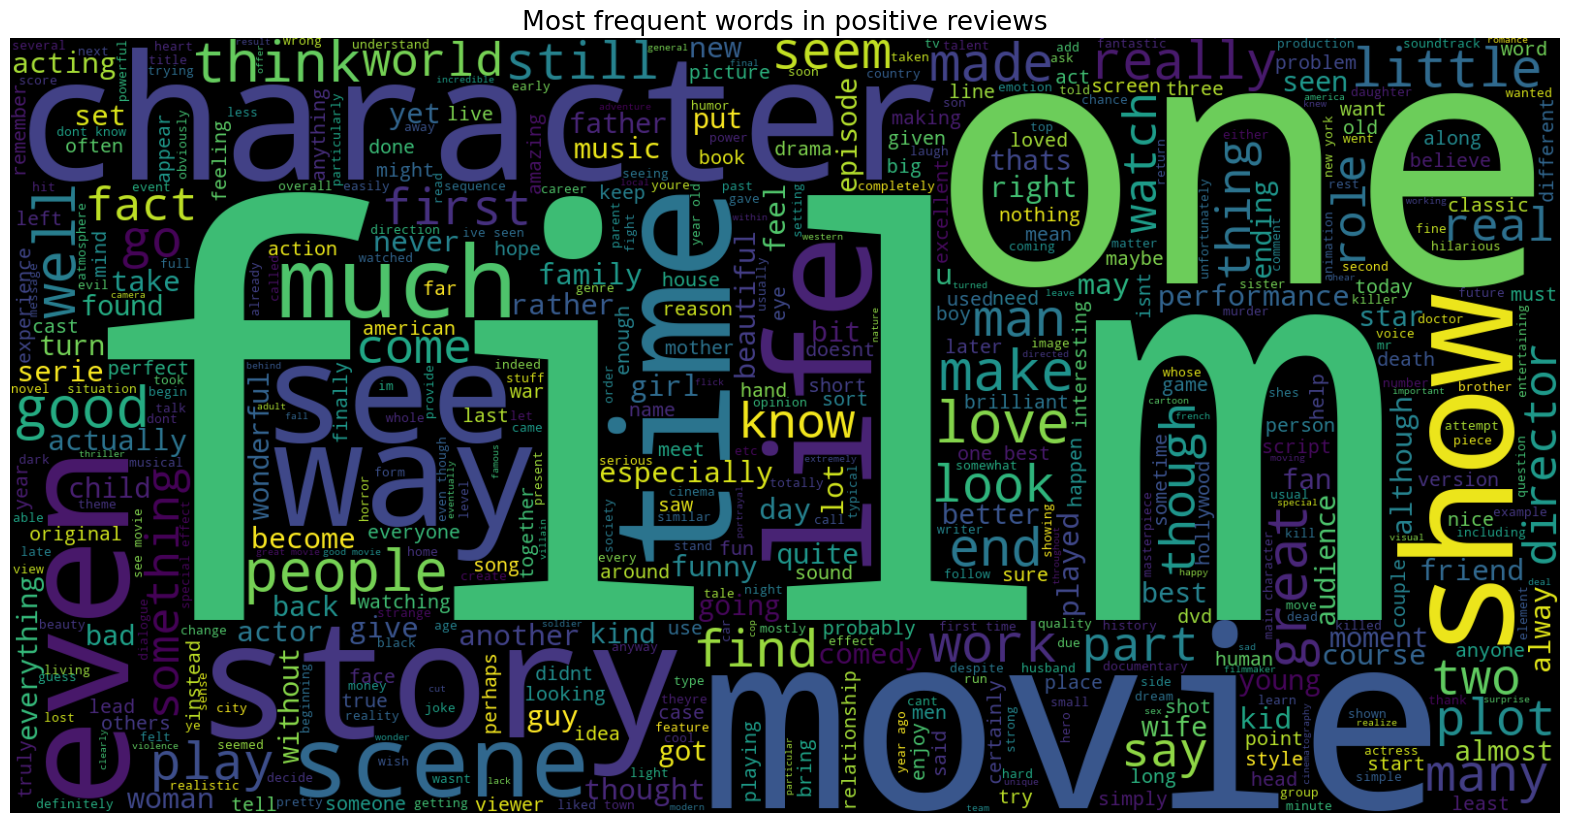

In [15]:
from wordcloud import WordCloud

text = ' '.join([word for word in pos['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in positive reviews', fontsize = 19)
plt.show()

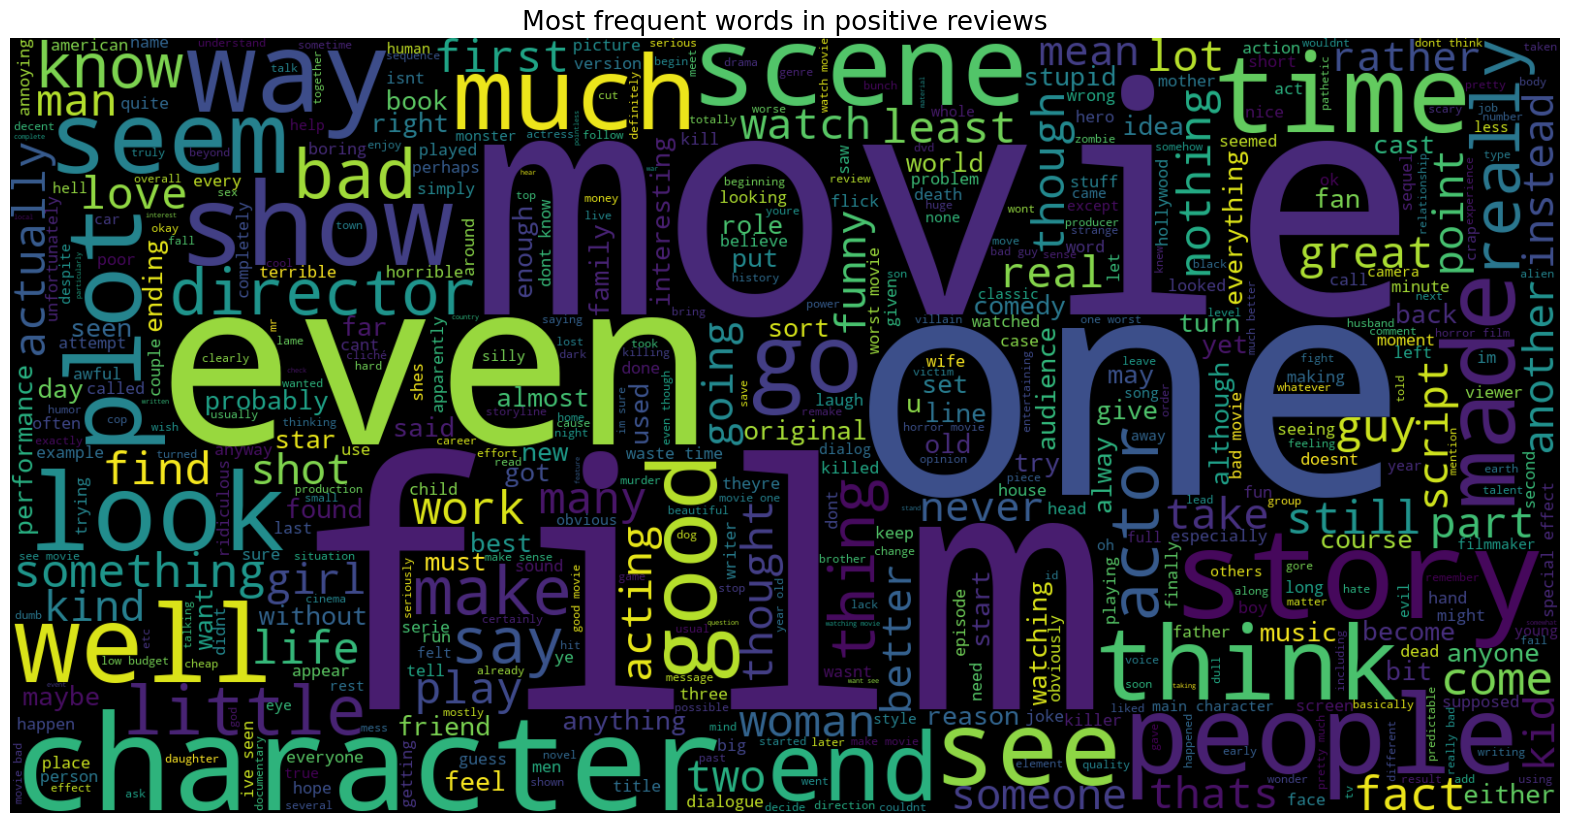

In [16]:
text = ' '.join([word for word in neg['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in positive reviews', fontsize = 19)
plt.show()

### Mã hoá nhãn

In [11]:
df['sentiment'] = df['sentiment'].map({'negative': 0, 'positive': 1})
df.head()

,review,sentiment
0,one reviewer mentioned watching 1 oz episode y...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically there family little boy jake think t...,0
4,petter matteis love time money visually stunni...,1


### Lưu data

In [ ]:
df.to_csv('../data/processed/IMDB Processed.csv', index=False)